# 2. SigMF files and carrier offset

Part one writes a [SigMF](https://sigmf.org) recording and reads it back, the way any other tool (GNU Radio, inspectrum,
`siggen analyze`) would. Part two uses NumPy on the samples to ask a question the EVM cannot answer: *how many symbols
would a receiver get wrong when the carrier is off by a few hertz?* This is the groundwork for a reference demodulator.

In [1]:
import pathlib, sys
sys.path.insert(0, str(pathlib.Path.cwd().parent))   # the python/ folder, when run from python/notebooks

import matplotlib.pyplot as plt
import numpy as np

import siggen

plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})
print("siggen library", siggen.version())

siggen library 0.5.0


## Write and read a SigMF recording

SigMF is a `.sigmf-data` file (little-endian float32 I/Q, datatype `cf32_le`) plus a `.sigmf-meta` JSON file with
the sample rate and datatype. siggen puts its own configuration under the `siggen:` namespace, so a recording it made
can be re-measured later, even after the samples were edited.

In [2]:
import json, tempfile

tmp = pathlib.Path(tempfile.mkdtemp())
tx = siggen.generate(modulation="QPSK", symbols=512, sps=8, snr_db=15)
tx.export(tmp / "qpsk.sigmf-data", "sigmf")           # same as: siggen --format sigmf -o qpsk.sigmf-data

meta = json.loads((tmp / "qpsk.sigmf-meta").read_text())
print(json.dumps({k: v for k, v in meta["global"].items() if k.startswith("core:")}, indent=2))
print("files:", sorted(p.name for p in tmp.iterdir()))

rx = siggen.load(tmp / "qpsk.sigmf-meta")
print("identical samples:", np.array_equal(rx.samples, tx.samples))
print(f"EVM from the file: {rx.symbol_accuracy().evm_percent:.2f} %")

{
  "core:datatype": "cf32_le",
  "core:sample_rate": 8000,
  "core:version": "1.0.0",
  "core:description": "Synthetic QPSK baseband signal from siggen",
  "core:recorder": "siggen"
}
files: ['qpsk.sigmf-data', 'qpsk.sigmf-meta']
identical samples: True
EVM from the file: 6.20 %


From a shell the same file is measured with `siggen analyze qpsk.sigmf-meta` (add `--json` for scripts).

## What a carrier offset does

A carrier frequency offset (CFO) rotates the whole constellation at `360 * f / baud` degrees per symbol. A **coherent**
receiver that decides on the absolute phase soon makes errors. A **differential** one (DQPSK) looks only at the phase
*change* between symbols, which the offset shifts by a small constant, so it keeps working until the shift reaches the
decision margin.

The decision rule below mirrors that. For coherent QPSK a symbol is wrong when its observation lies more than 45 degrees
from the transmitted point; for DQPSK a *step* is wrong when the received phase step is more than 45 degrees from the
transmitted one.

In [3]:
def symbol_error_rate(modulation, cfo_hz, snr_db=18, symbols=2000):
    tx = siggen.generate(modulation=modulation, symbols=symbols, sps=8, snr_db=snr_db, cfo_hz=cfo_hz)
    obs, idx = tx.matched_symbols()
    sym = tx.symbols[idx]
    if modulation.startswith("D"):                      # differential: compare phase steps
        obs, sym = obs[1:] * np.conj(obs[:-1]), sym[1:] * np.conj(sym[:-1])
    error = np.abs(np.angle(obs * np.conj(sym))) > np.pi / 4
    return error.mean(), tx.symbol_accuracy().evm_percent

for cfo in (0, 1, 5):
    q, q_evm = symbol_error_rate("QPSK", cfo)
    d, d_evm = symbol_error_rate("DQPSK", cfo)
    print(f"CFO {cfo:>2} Hz:  QPSK errors {q:6.1%} (EVM {q_evm:6.1f} %)   DQPSK errors {d:6.1%} (EVM {d_evm:6.1f} %)")

CFO  0 Hz:  QPSK errors   0.0% (EVM    4.5 %)   DQPSK errors   0.0% (EVM    4.5 %)
CFO  1 Hz:  QPSK errors  75.9% (EVM  142.2 %)   DQPSK errors   0.0% (EVM  142.2 %)
CFO  5 Hz:  QPSK errors  75.7% (EVM  142.2 %)   DQPSK errors   0.0% (EVM  142.1 %)


Note the EVM column: for QPSK it explodes (the coherent measurement sees the rotating constellation), but for DQPSK the
EVM is just as large and **says nothing about errors**, which stay low. EVM against the transmitted constellation is only
a quality measure when a receiver has first removed the rotation.

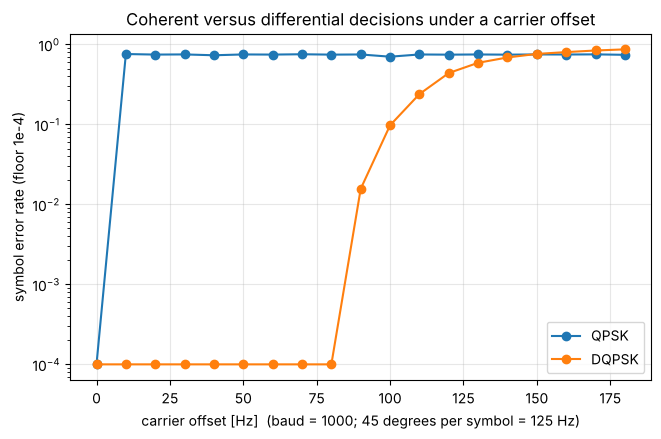

In [4]:
cfos = np.arange(0, 181, 10)
ser = {m: [symbol_error_rate(m, f)[0] for f in cfos] for m in ("QPSK", "DQPSK")}

plt.figure(figsize=(7.5, 4.5))
for name, values in ser.items():
    plt.semilogy(cfos, np.maximum(values, 1e-4), "o-", label=name)
plt.xlabel("carrier offset [Hz]  (baud = 1000; 45 degrees per symbol = 125 Hz)"); plt.ylabel("symbol error rate (floor 1e-4)")
plt.title("Coherent versus differential decisions under a carrier offset"); plt.legend(); plt.show()

## Next

With `matched_symbols()`, `symbols` and the files above, a reference demodulator (carrier recovery, decisions, bit
counting, BER against Eb/N0) is a small amount of NumPy that can be checked against the generator, and later moved into
the C++ library and the GUI.